# **Project Name**    - Uber EDA Project



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**            - Merugumala Rishitha

# **Project Summary -**

Uber Technologies, Inc. is an American multinational company that provides ride-hailing services, courier services, food delivery, and freight transport. It is headquatered in San Francisco, Califonia, and operates in approximately 70 countries and 15,000 cities worldwide. It is the largest ridesharing company worldwide with over 150 million monthly active users and 6 million active drivers and couriers. It coordinates an average of 28 million trips per day, and has coordinated 47 billion trips since its inception in 2010. In 2023, the company had a take rate(revenue as a percentage of gross bookings) of 28.7% for mobility services and 18.3% for food delivery. We have given a dataset through which we have to analyze the demand and supply gap for Uber Company by doing EDA operation on given dataset.

# **GitHub Link -**

https://github.com/Rishitha-1806/Uber_Trip_Analysis

# **Problem Statement**


We have given a dataset on which we have to do EDA operation to analyze and solve problems for the Uber Demand Gap through it?

#### **Define Your Business Objective?**

The following are the business objective for this project:

1. To find the reason of cancellation of the cab rides by drivers.
2. To find the solution to increase the transparency of cab ride fairs.
3. To find the permanent solution to customer problems so that to increase customer engagement and customer satisfaction rate.
4. To find various method to increase customer enagagement to use this app over other apps and ultimately increase profits for the organization.
5. To find solution to increase safety of cab rides specially in night time.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.express as px
import random
from wordcloud import WordCloud
import ast
import statsmodels as stat
import geopandas as geo
import missingno as ms

### Dataset Loading

In [5]:
# Load Dataset
import pandas as pd

md = pd.read_csv(r"C:\Users\MERUGUMALA RISHITHA\Downloads\Uber Project\Uber Request Data.csv")

### Dataset First View

In [6]:
# Dataset First Look
md.head(5)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Trips by Hour,Request by Day
0,1363,Airport,136.0,Trip Completed,2016-07-11 00:00:00,2016-07-11 01:11:00,0,Monday
1,1,Airport,285.0,Trip Completed,2016-07-11 00:20:00,2016-07-11 00:51:00,0,Monday
2,3,Airport,80.0,Trip Completed,2016-07-11 00:24:00,2016-07-11 01:31:00,0,Monday
3,5,Airport,264.0,Trip Completed,2016-07-11 00:36:00,2016-07-11 01:35:00,0,Monday
4,9,Airport,235.0,Trip Completed,2016-07-11 00:45:00,2016-07-11 02:00:00,0,Monday


In [7]:
# Dataset tail look
md.tail(5)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp,Trips by Hour,Request by Day
6740,6571,City,54.0,Cancelled,2016-07-15 21:16:00,NaN,21,Friday
6741,6647,City,78.0,Cancelled,2016-07-15 22:02:00,NaN,22,Friday
6742,6669,City,106.0,Cancelled,2016-07-15 22:12:00,NaN,22,Friday
6743,6717,City,67.0,Cancelled,2016-07-15 23:12:00,NaN,23,Friday
6744,6759,City,125.0,Cancelled,2016-07-15 23:59:00,NaN,23,Friday


### Dataset Rows & Columns count

In [8]:
# Dataset Rows & Columns count
md.shape

(6745, 8)

### Dataset Information

In [9]:
# Dataset Info
md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
 6   Trips by Hour      6745 non-null   int64  
 7   Request by Day     6745 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 421.7+ KB


#### Duplicate Values

In [10]:
# Dataset Duplicate Value Count
# Check for duplicate values
duplicates = md.duplicated(keep=False)

#Count the duplicate values
duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    6745
Name: count, dtype: int64


#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
Trips by Hour           0
Request by Day          0
dtype: int64

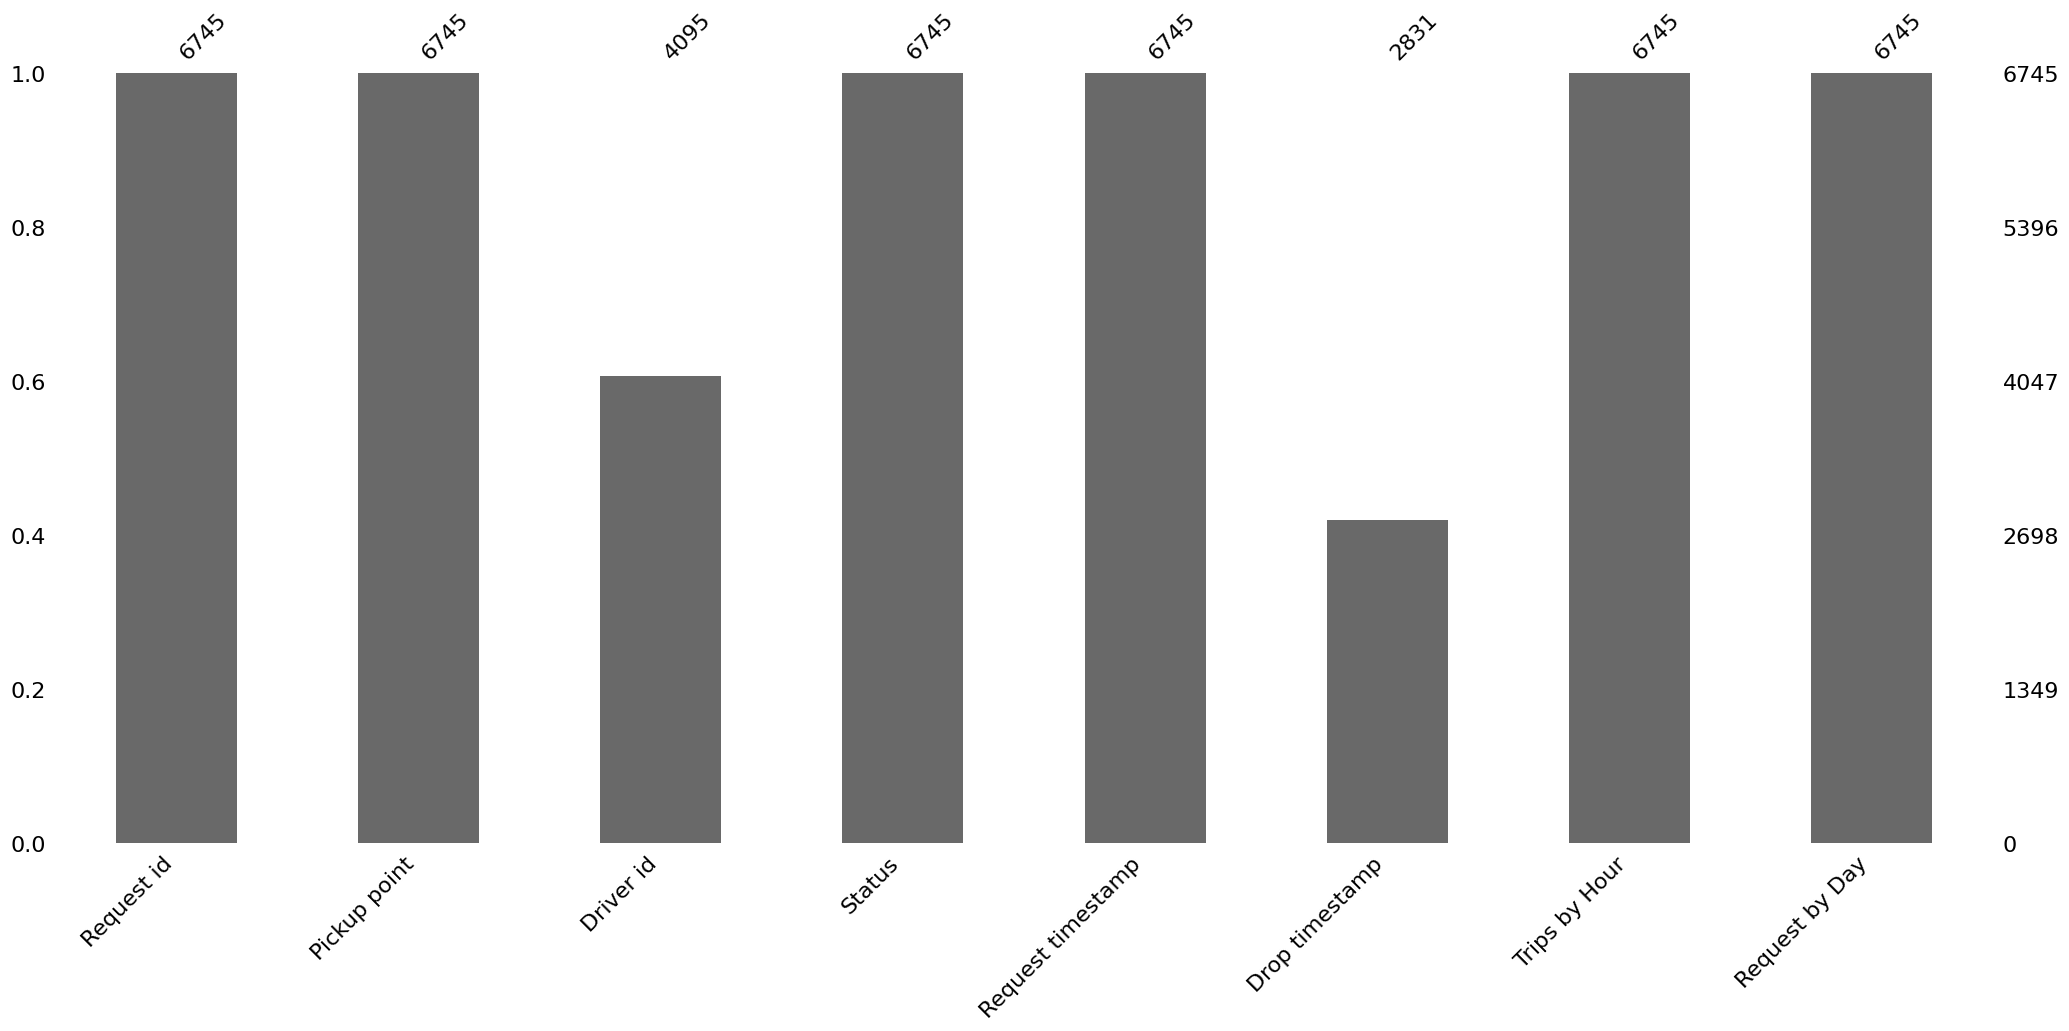

In [14]:
# Visualizing the missing values
ms.bar(md)
plt.show()

### What did you know about your dataset?

The following are the major points about the dataset-

1. The dataset contains 6 columns and 6745 rows
2. There are no duplicate values in the dataset

Following 2 columns are having some missing values -

Driver id ------ 2650

Drop timestamp ------ 3914

## ***2. Understanding Your Variables***

In [12]:
# Dataset Columns
md.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp', 'Trips by Hour',
       'Request by Day'],
      dtype='object')

In [13]:
# Dataset Describe
md.describe()

,Request id,Driver id,Trips by Hour
count,6745.000000,4095.000000,6745.000000
mean,3384.644922,149.501343,12.956709
std,1955.099667,86.051994,6.504052
min,1.000000,1.000000,0.000000
25%,1691.000000,75.000000,7.000000
50%,3387.000000,149.000000,13.000000
75%,5080.000000,224.000000,19.000000
max,6766.000000,300.000000,23.000000


### Variables Description

The following are the variables with their description:

1. Request id -------------------- Customer Unique id who requested for the cab service through app.
2. Pickup point -------------------- Pickup location to pickup the customer.
3. Driver id -------------------- Unique id of driver who is driving the cab.
4. Status -------------------- status of trip that if it got completed, cancelled or no cabs are available.
5. Request timestamp -------------------- Request time and date when the customer requested for the cab service.
6. Drop timestamp -------------------- Drop time and date when the customer is dropped to their respective location.
7. Trips by Hour -------------------- Trips that has been requested per hour.
8. Requests by day -------------------- Trips that has been requested per day.

The above are the description for the variables present in the dataset.

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable.
for x in md.columns:
    print(f"{x} - {md[x].nunique()}")

Request id - 6745
Pickup point - 2
Driver id - 300
Status - 3
Request timestamp - 4016
Drop timestamp - 2282
Trips by Hour - 24
Request by Day - 5


## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
# Write your code to make your dataset analysis ready.
# Checking for the null values in the dataset
md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
Trips by Hour           0
Request by Day          0
dtype: int64

In [17]:
md.fillna({"Driver id": "Not Available"},inplace=True)

In [18]:
md.fillna({"Drop timestamp": "Not Available"},inplace=True)

In [19]:
# Checking that the missing values are present or removes
md.isnull().sum()

Request id           0
Pickup point         0
Driver id            0
Status               0
Request timestamp    0
Drop timestamp       0
Trips by Hour        0
Request by Day       0
dtype: int64

### What all manipulations have you done and insights you found?

The following manipulation we have done to our dataset:

1. As there were no duplicates so no issue of removing it.
2. There are total 2 columns having missing values which we replaced with Not Available value.

Driver id ------- 2650

Drop timestamp ------- 3914

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

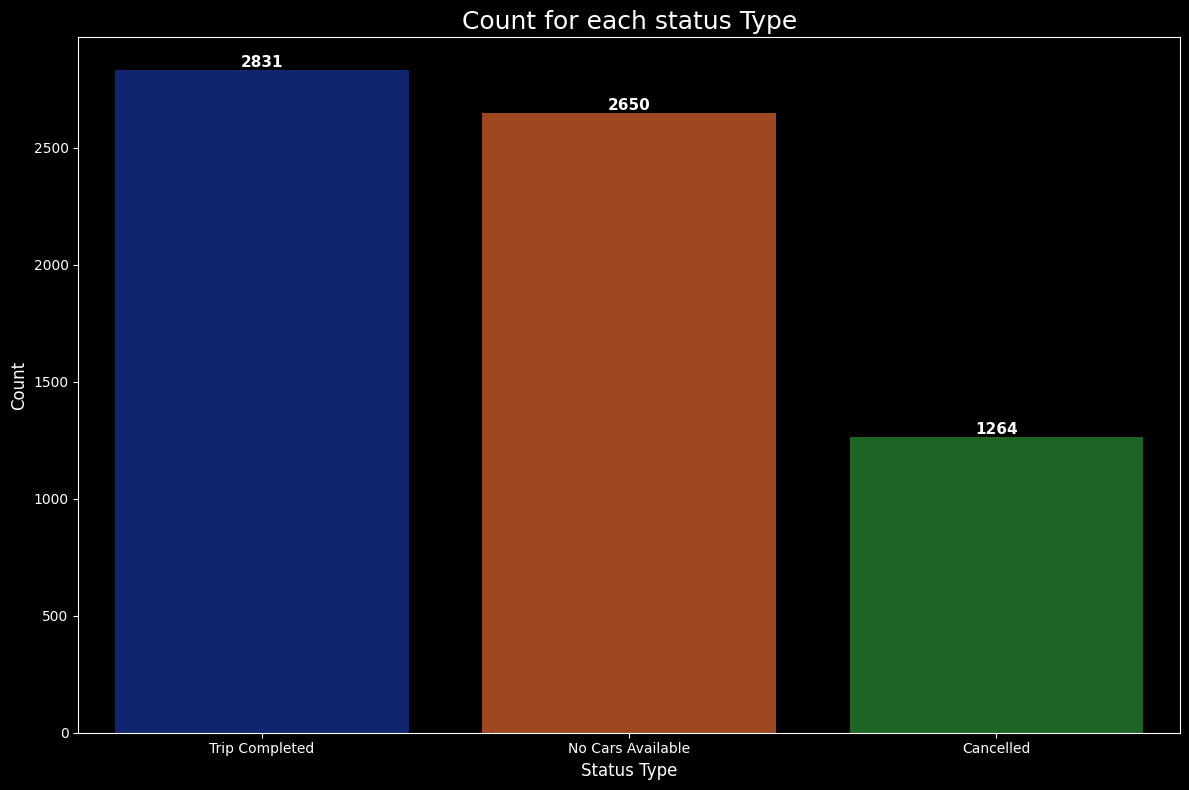

In [20]:
# Chart - 1 visualization code
plt.style.use('dark_background')
md.columns = md.columns.str.strip()
plt.figure(figsize=(12,8))
ax = sns.countplot(x='Status', data = md, hue="Status", palette="dark", legend=0)
plt.title('Count for each status Type', fontsize=18)
plt.xlabel('Status Type', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x,y),
        ha = 'center',
        va = 'bottom',
        fontsize = 11,
        color = 'white',
        fontweight = 'bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show() 

##### 1. Why did you pick the specific chart?

The above barchart gives clear count for status type.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:

1. Highest count is for Trip completed status which is 2831.
2. Second highest count is for No Cars Available status which is 2650.
3. Lowest count is for Cancelled status which is 1264.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that maximum cars have completed their trip but almost equal no of cars have not completed trip as they were not available at the moment, which means uber has to increase its car numbers so as to increase availability of cars for customers and increase profits for the organisation.

#### Chart - 2

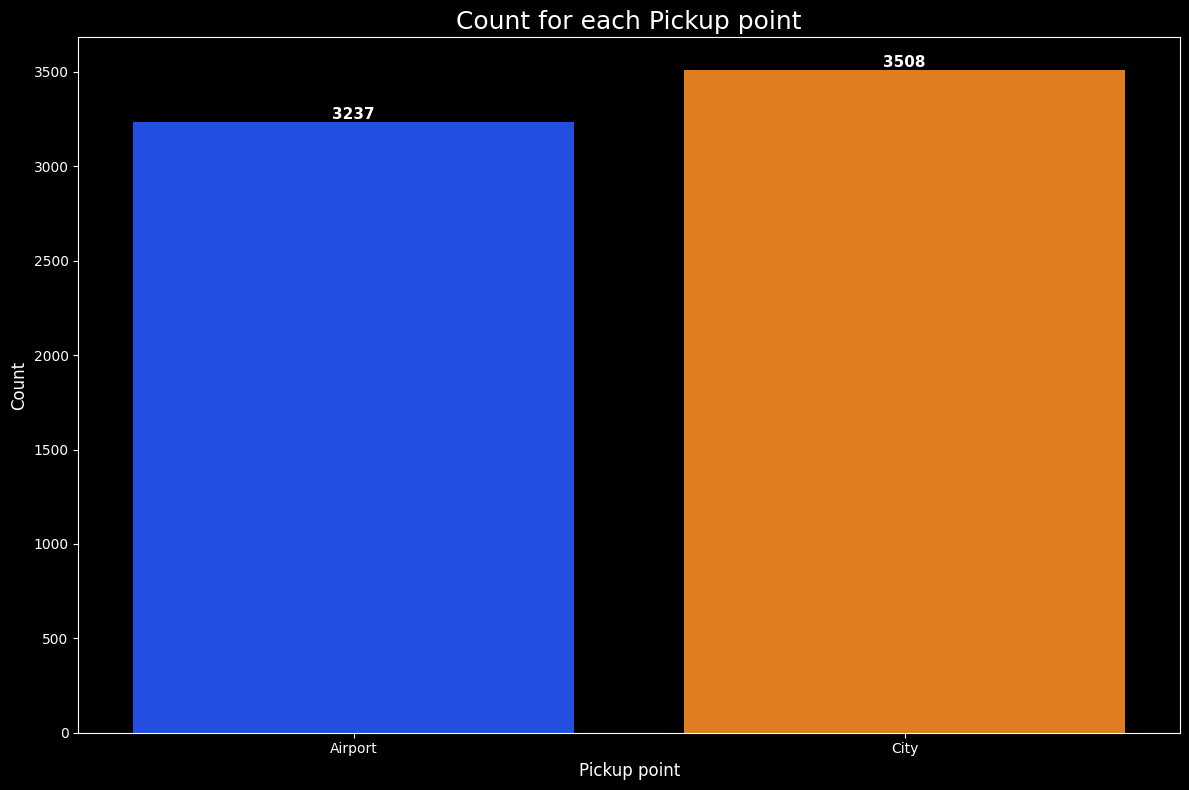

In [21]:
# Chart - 2 visualization code
plt.style.use('dark_background')
md.columns = md.columns.str.strip()
plt.figure(figsize=(12,8))
ax = sns.countplot(x='Pickup point', data = md, hue="Pickup point", palette="bright", legend=0)
plt.title('Count for each Pickup point', fontsize=18)
plt.xlabel('Pickup point', fontsize=12)
plt.ylabel('Count', fontsize=12)
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x,y),
        ha = 'center',
        va = 'bottom',
        fontsize = 11,
        color = 'white',
        fontweight = 'bold'
    )

plt.grid(False)
plt.tight_layout()
plt.show() 

##### 1. Why did you pick the specific chart?

The above bar chart gives clear count for pickup point.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:

1. Highest count is for city pickup point which is 3507.
2. Lowest count is for airport pickup which is 3238.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights show that people often prefer uber services inside city commute rather than airport commute which means company can do campaigns and offer some discounts on premium uber black service if customer books it from airport to ultimately increase profits of company.

#### Chart - 3

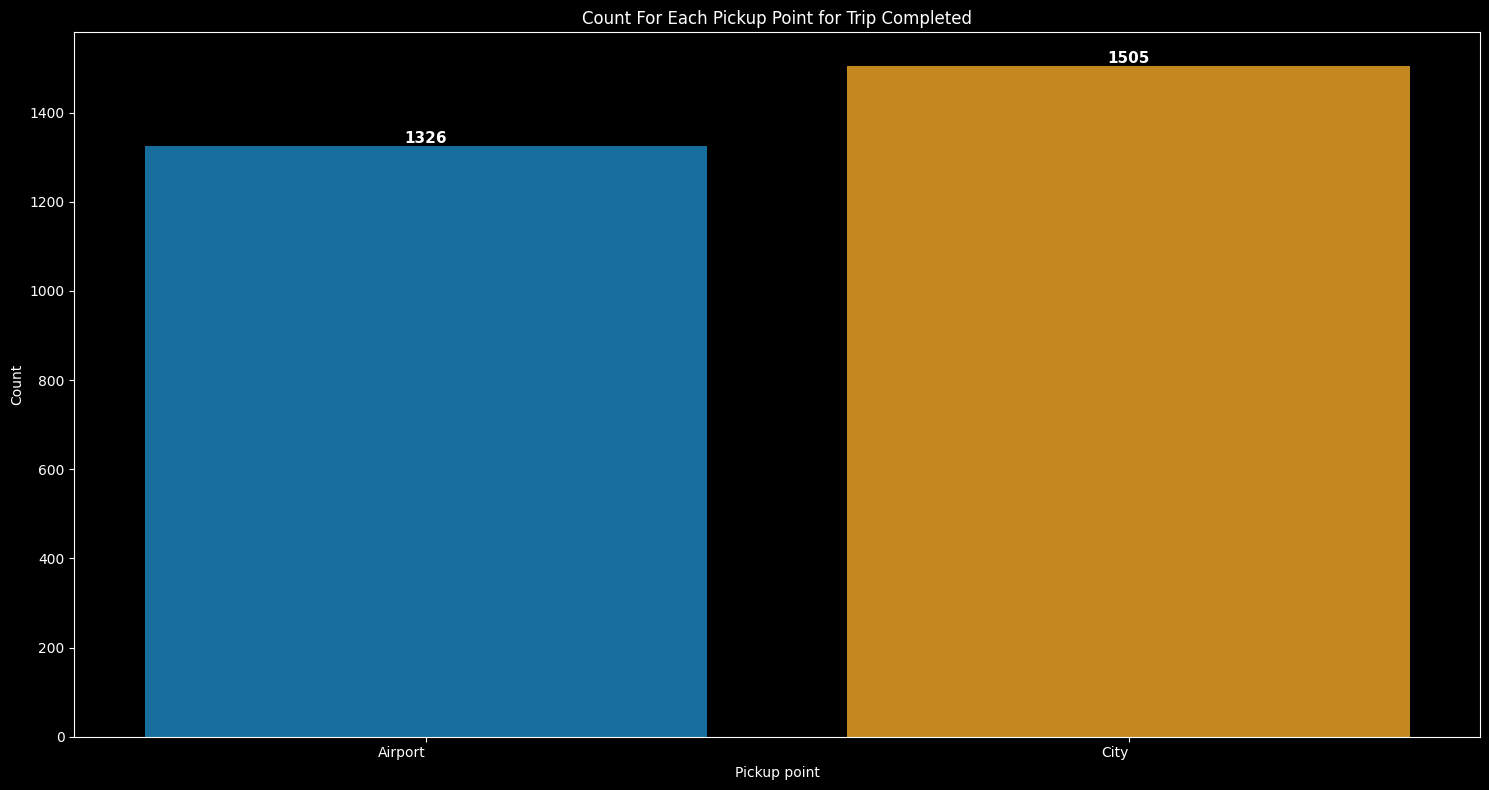

In [22]:
# Chart - 3 visualization code

plt.style.use('dark_background')
trip_c = md[md.Status == 'Trip Completed'].groupby('Pickup point')['Pickup point'].count()
trip_c_1 = pd.DataFrame(trip_c)
# Rename the count column
trip_c_1.rename(columns={'Pickup point': 'count'}, inplace=True)
trip_c_1.reset_index(inplace=True)
# Create a bar plot
plt.figure(figsize=(15, 8))  # Adjust figure size
ax = sns.barplot(data=trip_c_1,x="Pickup point",y="count",hue="Pickup point",palette="colorblind",legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha="right")
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count For Each Pickup Point for Trip Completed")

for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()

    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',
        fontweight='bold'
    )
plt.grid(False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:

1. For trip completed status the highest count is for city which is 1504.
2. For trip completed status the lowest count is for airport which is 1327.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

As per the above insights, it shows that almost equal number of count is their for trip completion status for both pickup point which is great positive sign but, company can improve a little bit for airport pickup point to increase overall customer satisfaction and profits.

#### Chart - 4

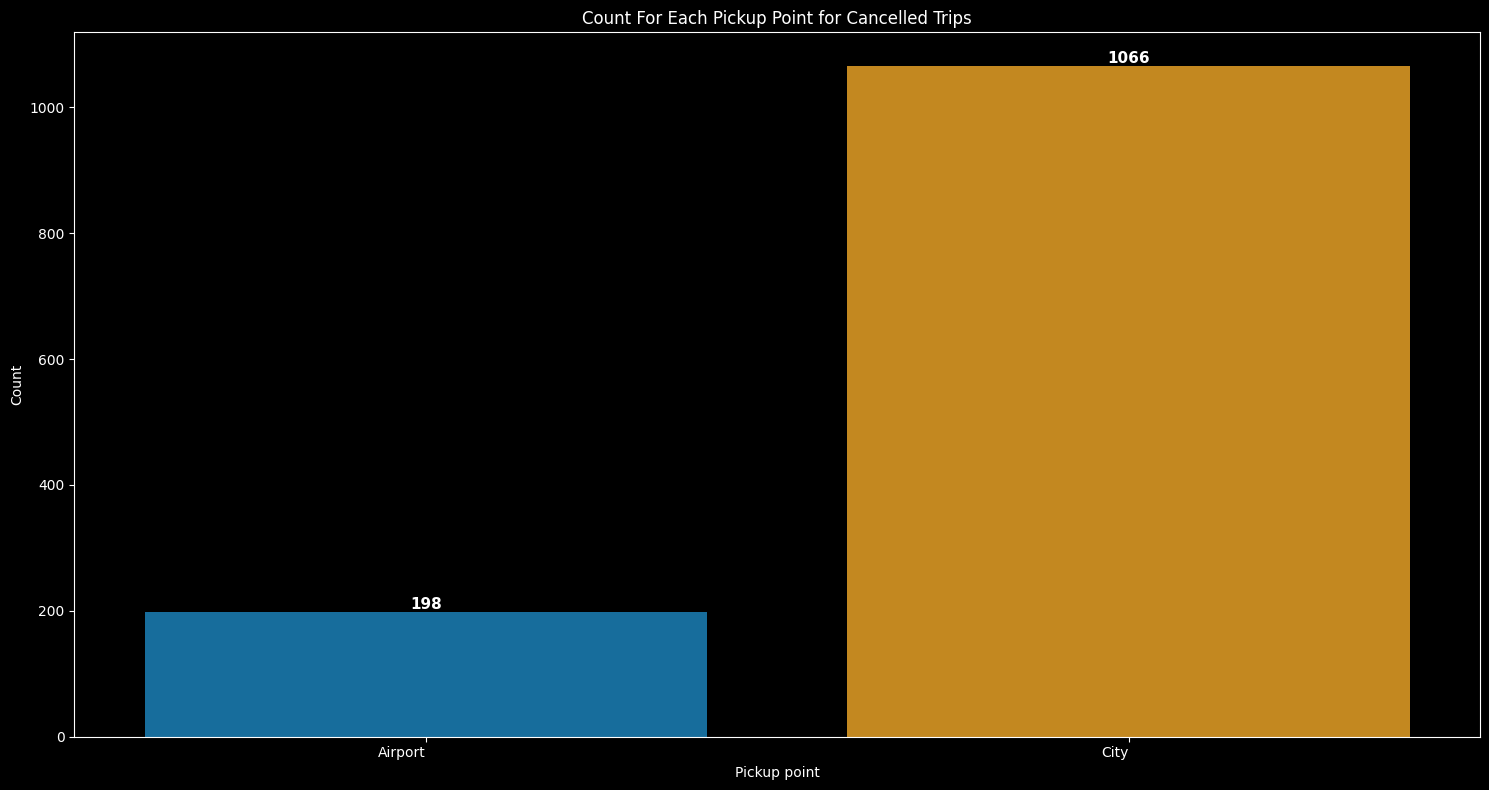

In [23]:
# Chart - 4 visualization code
plt.style.use('dark_background')
cancel = md[md.Status == 'Cancelled'].groupby('Pickup point')['Pickup point'].count()
cancel_1 = pd.DataFrame(cancel)
# Rename the count column
cancel_1.rename(columns={'Pickup point': 'count'}, inplace=True)
cancel_1.reset_index(inplace=True)
# Create a bar plot
plt.figure(figsize=(15, 8))  # Adjust figure size
ax = sns.barplot(data=cancel_1,x="Pickup point",y="count",hue="Pickup point",palette="colorblind",legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha="right")
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count For Each Pickup Point for Cancelled Trips")

for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()

    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',
        fontweight='bold'
    )
plt.grid(False)
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:

1. For Cancelled Trips status the highest count is for city which is 1066.
2. For Cancelled Trips status the lowest count is for airport which is 198.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows a very negative aspect,as we know already that the count for pickup point city is greater than airport and here we can see that the maximum count of cancelled trips is for city pickup point which shows a bad impression that customer requests are not followed by drivers,this can ultimately reduce company rating so as to avoid this company should monitor on drivers who cancelling rides inside city commute so as to increase future customer engagement and overall companu reputation.

#### Chart - 5

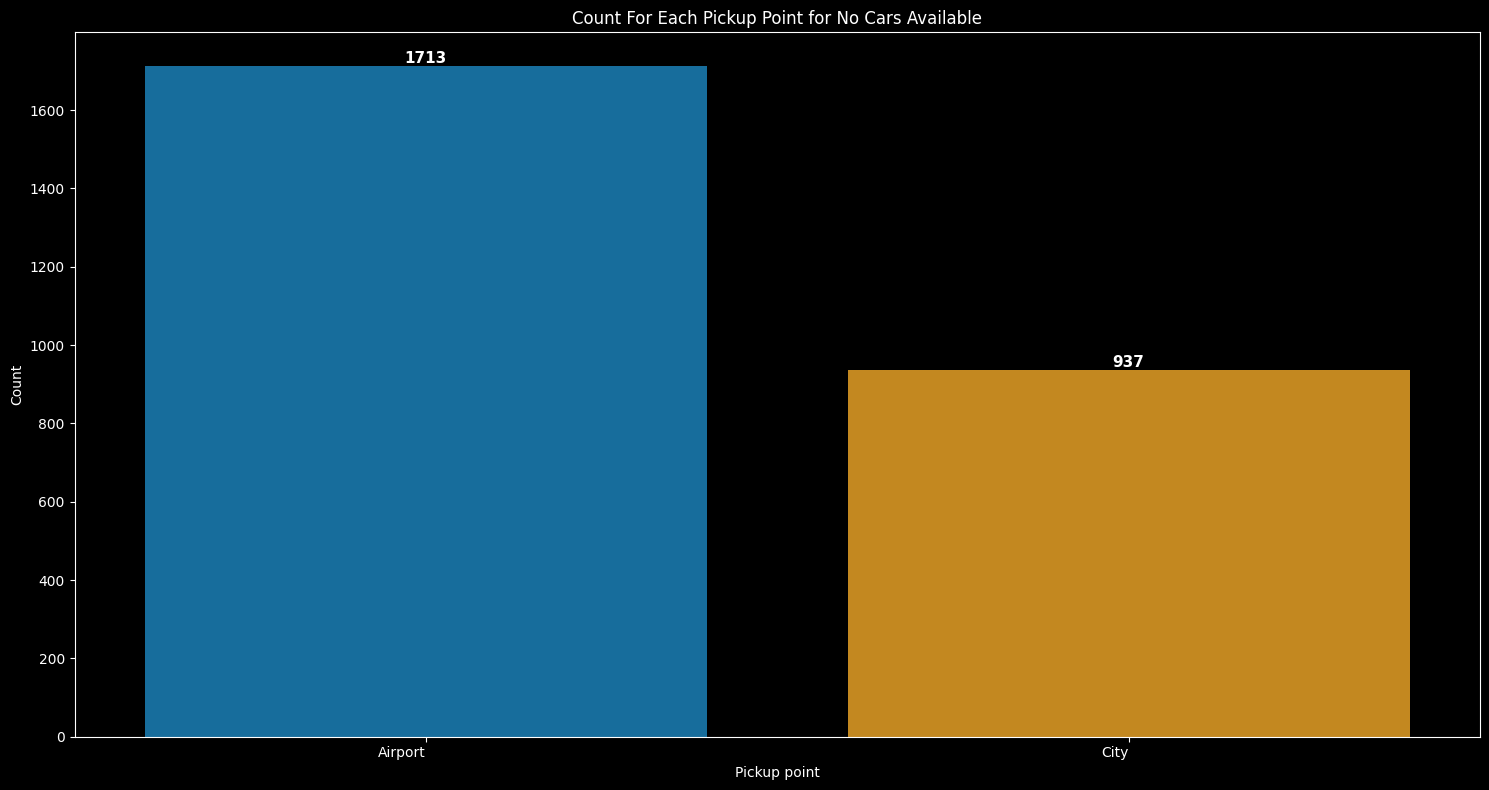

In [24]:
# Chart - 5 visualization code
plt.style.use('dark_background')
nocars = md[md.Status == 'No Cars Available'].groupby('Pickup point')['Pickup point'].count()
nocars_1 = pd.DataFrame(nocars)
# Rename the count column
nocars_1.rename(columns={'Pickup point': 'count'}, inplace=True)
nocars_1.reset_index(inplace=True)
# Create a bar plot
plt.figure(figsize=(15, 8))  # Adjust figure size
ax = sns.barplot(data=nocars_1,x="Pickup point",y="count",hue="Pickup point",palette="colorblind",legend=False)

# Rotate x-axis labels for better readability
plt.xticks(rotation=0, ha="right")
plt.xlabel("Pickup point")
plt.ylabel("Count")
plt.title("Count For Each Pickup Point for No Cars Available")

for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()

    ax.annotate(
        str(count),
        (x, y),
        ha='center',
        va='bottom',
        fontsize=11,
        color='white',
        fontweight='bold'
    )
plt.grid(False)
plt.tight_layout()
plt.show()



##### 1. Why did you pick the specific chart?

Bar plot gives clear count when using group by functions.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above plot:

1. For no cars available status the highest count is for airport which is 1713.
2. For no cars available status the lowest count is for city which is 937.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights show that maximum cars are not available at pickup point where the most of the business comes for any cab service company, so if uber wants to increase its profits it should provide more number of cars at airport so as to not miss the opportunity of earn and retain frequent flyers who commute through airport and use cab services.

#### Chart - 6

In [25]:
# Chart - 6 visualization code
plt.style.use('dark_background')

# Ensure clean column names
md.columns = md.columns.str.strip()

# Filter for pickup point = 'Airport'
airport_df = md[md['Pickup point'].str.strip() == 'Airport']

# Group by Status and count
type_count = airport_df['Status'].value_counts().reset_index()
type_count.columns = ['Status', 'Count']

# Create the tree map
fig = px.treemap(type_count,
                 path=['Status'],
                 values='Count',
                 title="Count of Status for airport",
                 color='Count',
                 color_continuous_scale="RdBu")

# Show the plot
fig.show()

##### 1. Why did you pick the specific chart?

The above map gives clear details when we hover over it and helps us to compare various variables in single tree map.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above tree map:

1. Highest count of airport status is for No cars Available which is 1713.
2. Second highest count of airport status is for Trip Completed which is 1327.
3. Lowest count of airport status is for cancelled which is 198.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the airport pickup point has less available cars because of which customers are preffering other cab services, if company wants to reduce or eliminate the competition than they have to allocate more cars at airport so as to increase customer engagement and profits.

#### Chart - 7

In [26]:
# Chart - 7 visualization code
plt.style.use('dark_background')

# Ensure clean column names
md.columns = md.columns.str.strip()

# Filter for pickup point = 'Airport'
City_df = md[md['Pickup point'].str.strip() == 'City']

# Group by Status and count
City_df_count = City_df['Status'].value_counts().reset_index()
City_df_count.columns = ['Status', 'Count']

# Create the tree map
fig = px.treemap(City_df_count,
                 path=['Status'],
                 values='Count',
                 title="Count of Status for City",
                 color='Count',
                 color_discrete_map={'(?)' : 'Lightgrey', 'Lunch': 'gold', 'Dinner': 'darkblue' })

# Show the plot
fig.show()


##### 1. Why did you pick the specific chart?

The above map gives clear details when we hover over it and helps us to compare various variables in single tree map.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above tree map:

1. Highest count of City status is for Trip Completed which is 1504.
2. Second highest count of City status is for cancelled which is 1066.
3. Lowest count of City status is for No cars Available which is 937.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

As we know already that the count for pickup point city is greater than airport and have we can see that the maximum count of cancelled trips is for city pickup point which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating so as to avoid this company should monitor on drivers who cancelling rides inside city commute so as to increase future customer engagement and overall company reputation.

#### Chart - 8

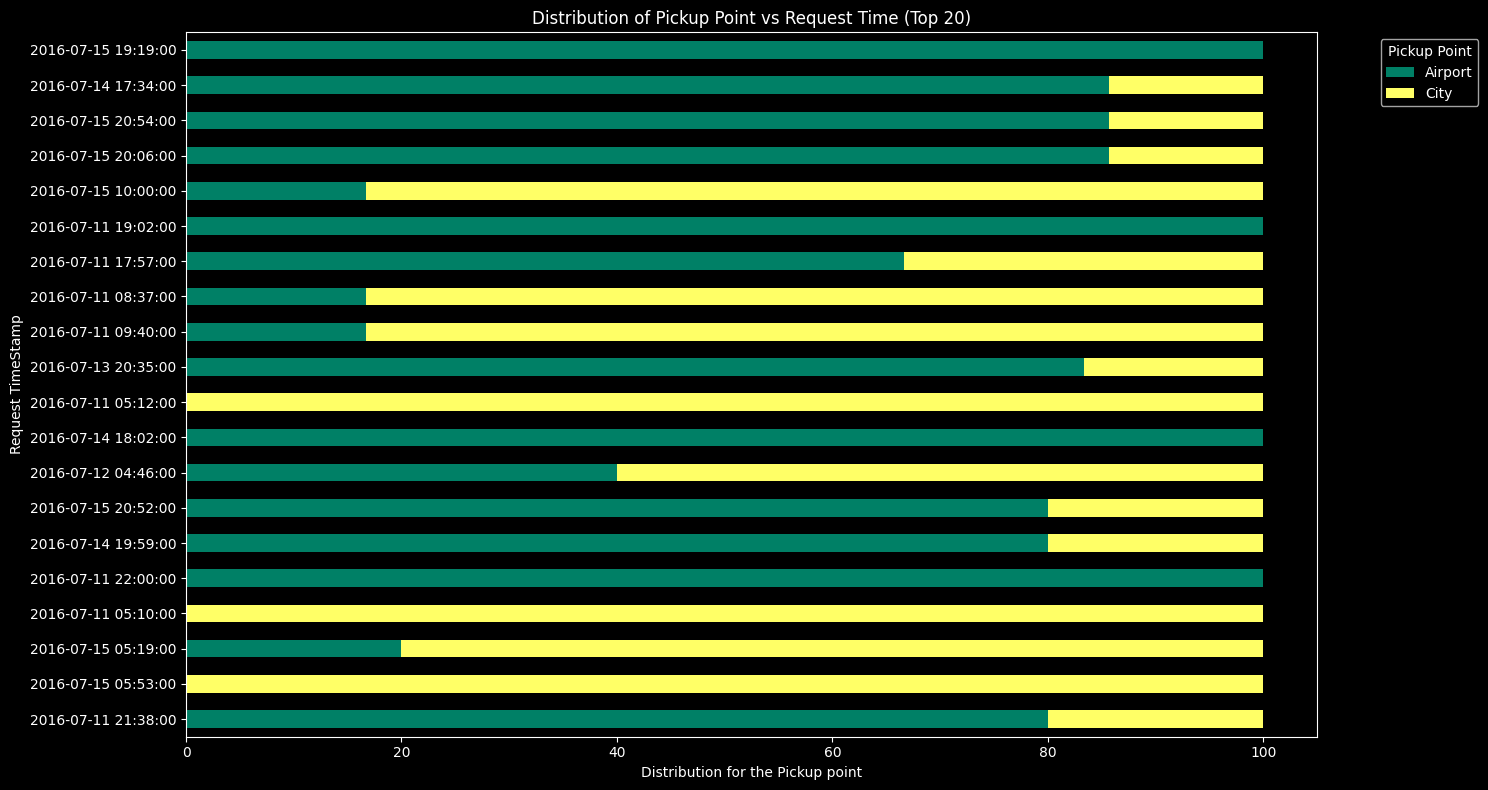

In [27]:
# Chart - 8 visualization code

P_1 = md.groupby(["Request timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
P_11 = P_1.div(P_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_P = P_1.sum(axis=1).sort_values(ascending=False).head(20).index
P_top20 = P_11.loc[top_P]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
P_top20.plot(kind="barh",stacked=True,colormap="summer",ax=ax)

# Labels and title
ax.invert_yaxis()
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Pickup Point vs Request Time (Top 20)")
plt.legend(title="Pickup Point",bbox_to_anchor=(1.05, 1),loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:

1. Airport pickups dominate during several evening request times, especially around 19:02, 19:19, 18:02, 22:00 where the Airport accounts for almost all requests.
2. City pickups dominate during early morning request times, such as 5:12, 5:53, 8:37, 9:40, and 10:00, indicating higher demand for city travel in the morning.
3. Some request times, such as show 17:57, 20:52, 19:59, 21:38 a more balanced distribution between Airport and City pickups, suggesting demand from both locations.
4. The pickup demand changes significantly throughout the day, indicating that customer travel patterns vary based on the time of day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights can help create a positive business impact by enabling Uber to allocate drivers according to demand.

1. More drivers should be positioned near city pickup points during the morning hours to meet higher demand.
2. More drivers should be deployed near the airport during the evening and night hours, where airport pickups are significantly higher.
3. Proper driver allocation can reduce passenger waiting time, minimize trip cancellations, improve driver utilization, and increase customer satisfaction.

#### Chart - 9

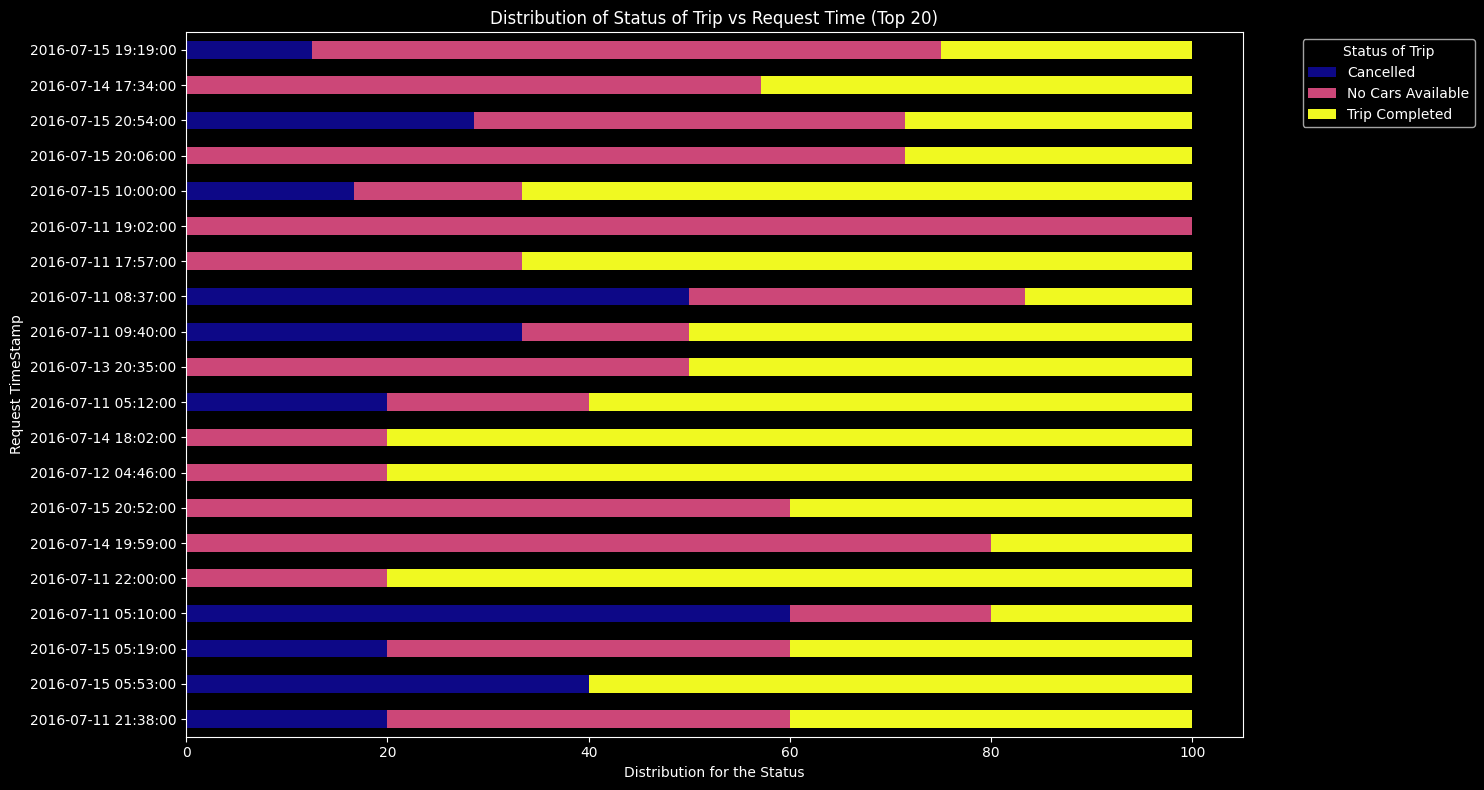

In [28]:
# Chart - 9 visualization code
S_1 = md.groupby(["Request timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
S_11 = S_1.div(S_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_S = S_1.sum(axis=1).sort_values(ascending=False).head(20).index
S_top20 = S_11.loc[top_P]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
S_top20.plot(kind="barh",stacked=True,colormap="plasma",ax=ax)

# Labels and title
ax.invert_yaxis()
plt.xlabel("Distribution for the Status")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Status of Trip vs Request Time (Top 20)")
plt.legend(title="Status of Trip",bbox_to_anchor=(1.05, 1),loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:

1. The highest count for no cars available status is for the request timestamp 19:02 on 11/7/2016.
2. The highest count for cancelled status is for the request timestamp 5:10 on 11/7/2016.
3. The highest count for Trip Completed is for the request timestamp 22:00,4:46 and 18:02 on different dates.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that the no cars available status is mostly for evening/ night time, cancelled status is mostly for morning time and trip completed status has equal no of count for both evening/ night and morning time. As per the morning drivers should be monitored constantly and they should be informed that to minimize the cancellation of cab services.

#### Chart - 10

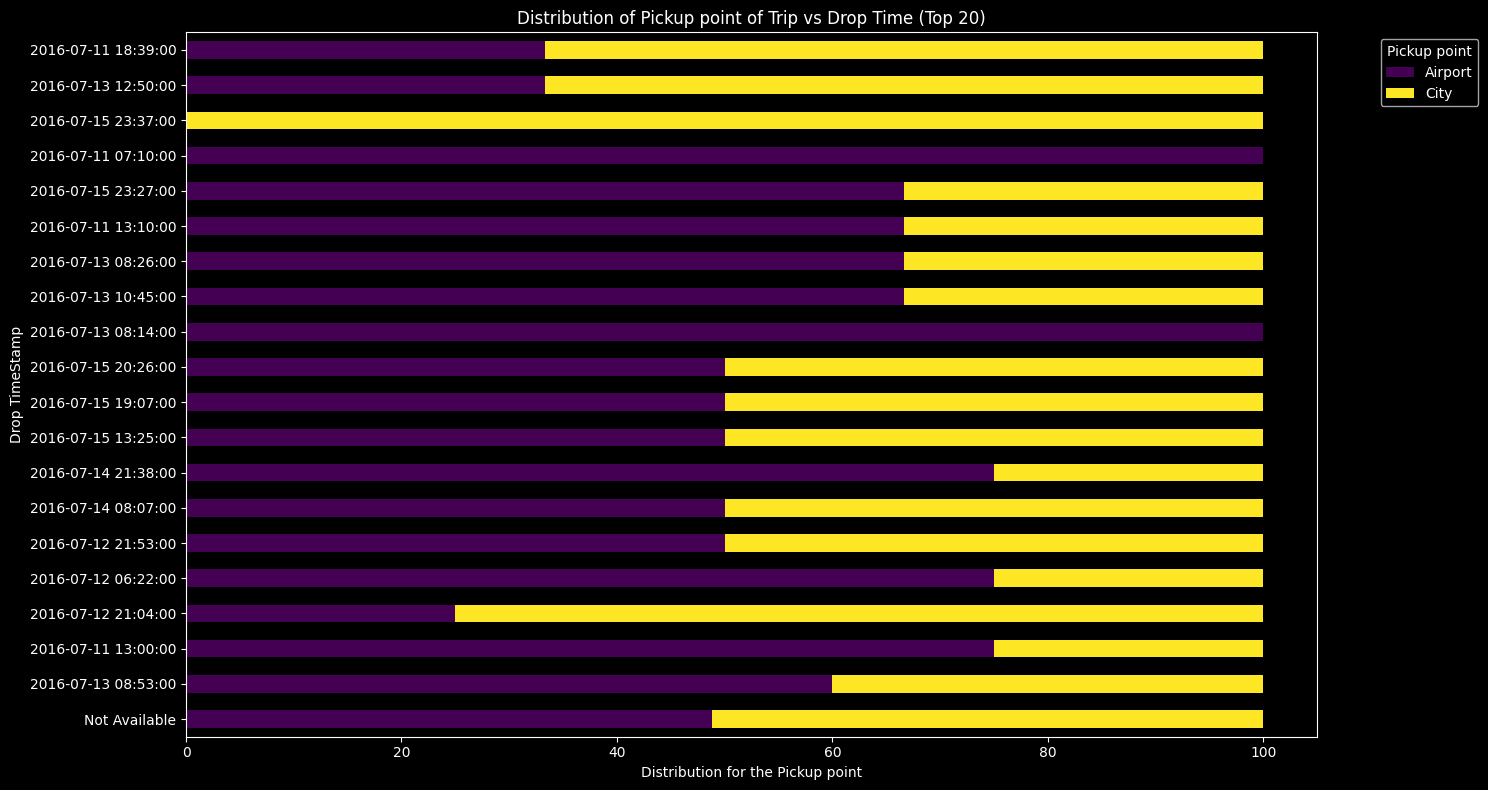

In [30]:
# Chart - 10 visualization code
Pd_1 = md.groupby(["Drop timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
Pd_11 = Pd_1.div(Pd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_Pd = Pd_1.sum(axis=1).sort_values(ascending=False).head(20).index
Pd_top20 = Pd_11.loc[top_Pd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
Pd_top20.plot(kind="barh",stacked=True,colormap="viridis",ax=ax)

# Labels and title
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Drop TimeStamp")
plt.title("Distribution of Pickup point of Trip vs Drop Time (Top 20)")
plt.legend(title="Pickup point",bbox_to_anchor=(1.05, 1),loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:

1. The highest count for airport pickup point is for the drop timestamps 13:00, 6:22 and 21:38 .
2. The highest count for City pickup point is for the drop timestamps 8:55 and 21:04.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights show that the airport and city pickup point both have high count for morning or afternoon drop timestamps, which means customers are reaching their destination/arrivals in the morning/ afternoon time.Remembering this drivers should be informed that not to cancel morning requests as it will impact company profits.

#### Chart - 11

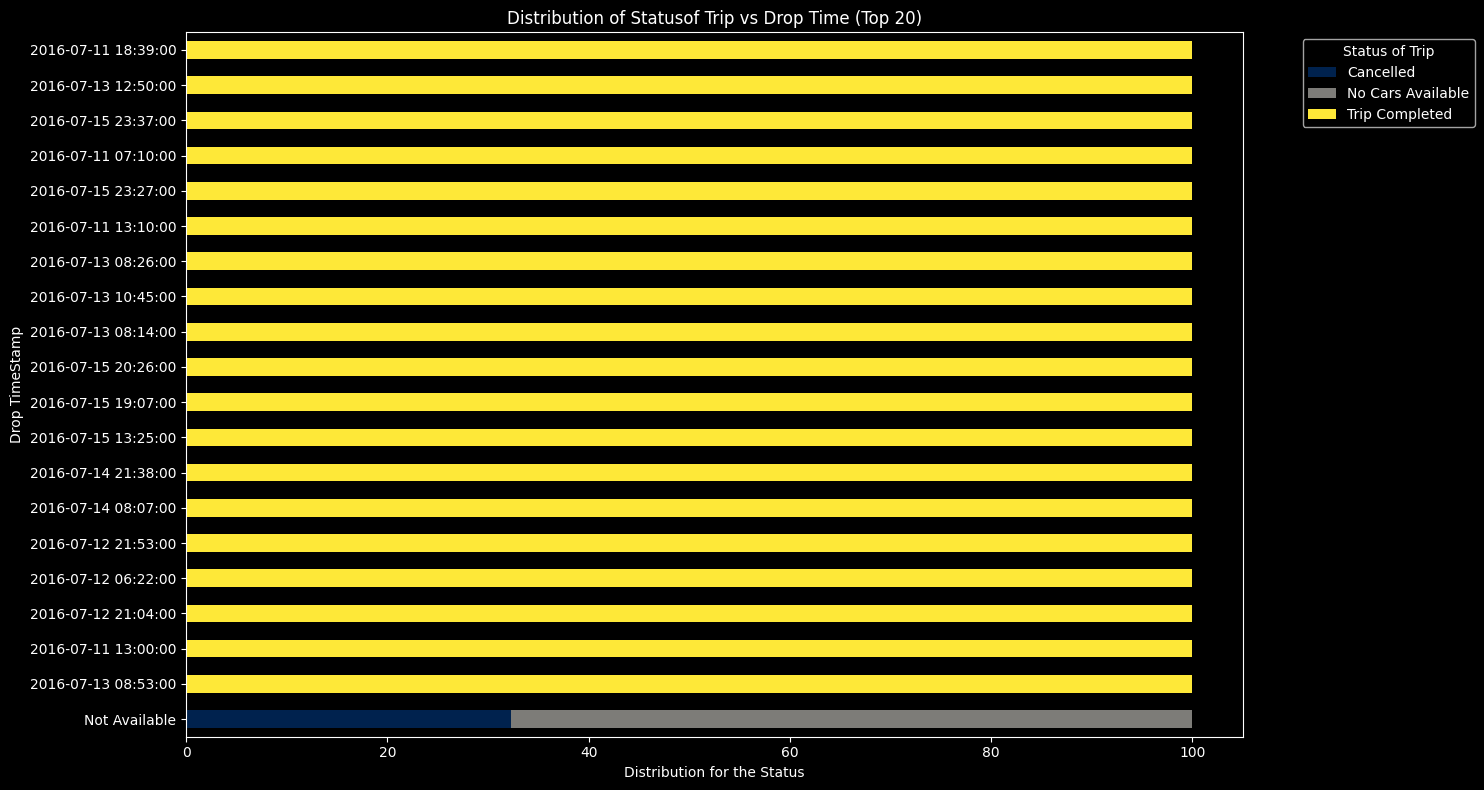

In [31]:
# Chart - 11 visualization code
Sd_1 = md.groupby(["Drop timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
Sd_11 = Sd_1.div(Pd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_Sd = Sd_1.sum(axis=1).sort_values(ascending=False).head(20).index
Sd_top20 = Sd_11.loc[top_Sd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
Sd_top20.plot(kind="barh",stacked=True,colormap="cividis",ax=ax)

# Labels and title
plt.xlabel("Distribution for the Status")
plt.ylabel("Drop TimeStamp")
plt.title("Distribution of Statusof Trip vs Drop Time (Top 20)")
plt.legend(title="Status of Trip",bbox_to_anchor=(1.05, 1),loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:

1. The highest count for no cars available status is for the morning drop timestamp with common date as 11/7/2016.
2. The highest count for cancelled status is for the morning drop timestamp with common date as 11/7/2016.
3. The highest count for the trip completed status is for the drop timestamps 18:39, 8:53, 13:00, 12:50, 23:37, 7:10, 23:27 and so on.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that the drop time is morning for all three status which means cancelled trips are mostly done in the morning which affects the business as most customers are travelling in the morning,the company should inform the drivers that if they cancel trips in morning than they have to face penalty as this will reduce cancellation and ultimately increase profits for the company.

#### Chart - 12

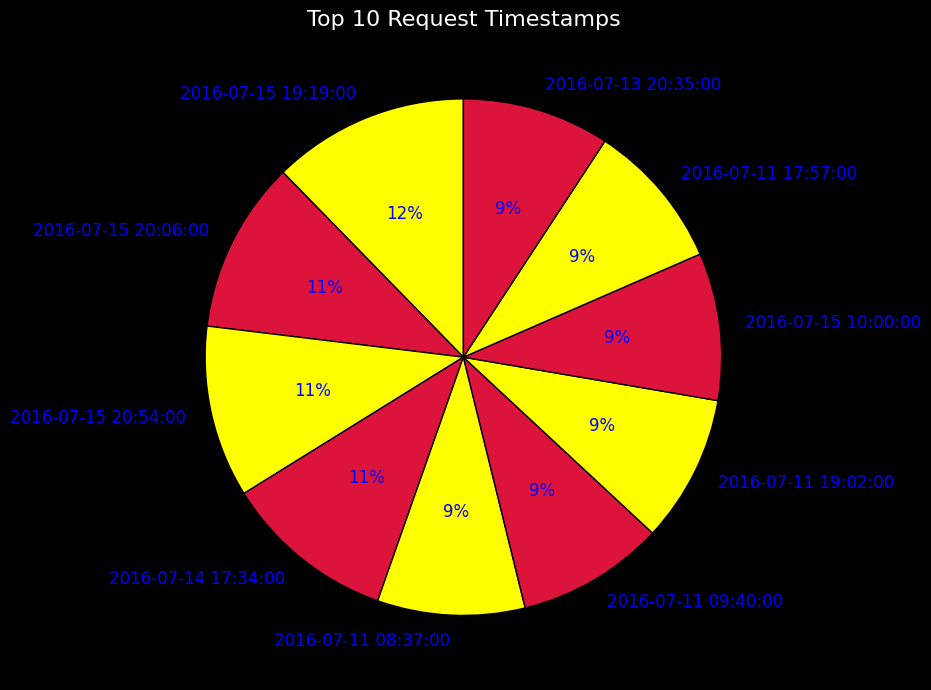

In [32]:
# Chart - 12 visualization code
co = md['Request timestamp'].value_counts().head(10)

# No conversion to int here
plt.figure(figsize=(15,7))
co.plot(
    kind='pie',
    labels=co.index,    #Keep as strings
    autopct=lambda p: '{:.0f}%'.format(p),
    colors=['yellow', 'crimson'],
    startangle =90,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontsize': 12, 'color': 'blue'}
)

plt.title('Top 10 Request Timestamps', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above pie chart gives clear distribution of request timestamps and help us to compare each of them with each other easily.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above pie chart:

1. The highest distribution is for the request time stamp 19:19 with 12% value and timestamps 17:34, 20:54,20:06 with 11% value each.
2. The lowest distribution is for the request time stamps 20:35, 9:40,8:37,17:57,19:02 and 10:00 with 9% values each.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the request time count is almost same for both morning/afternoon and evening/night time.

#### Chart - 13

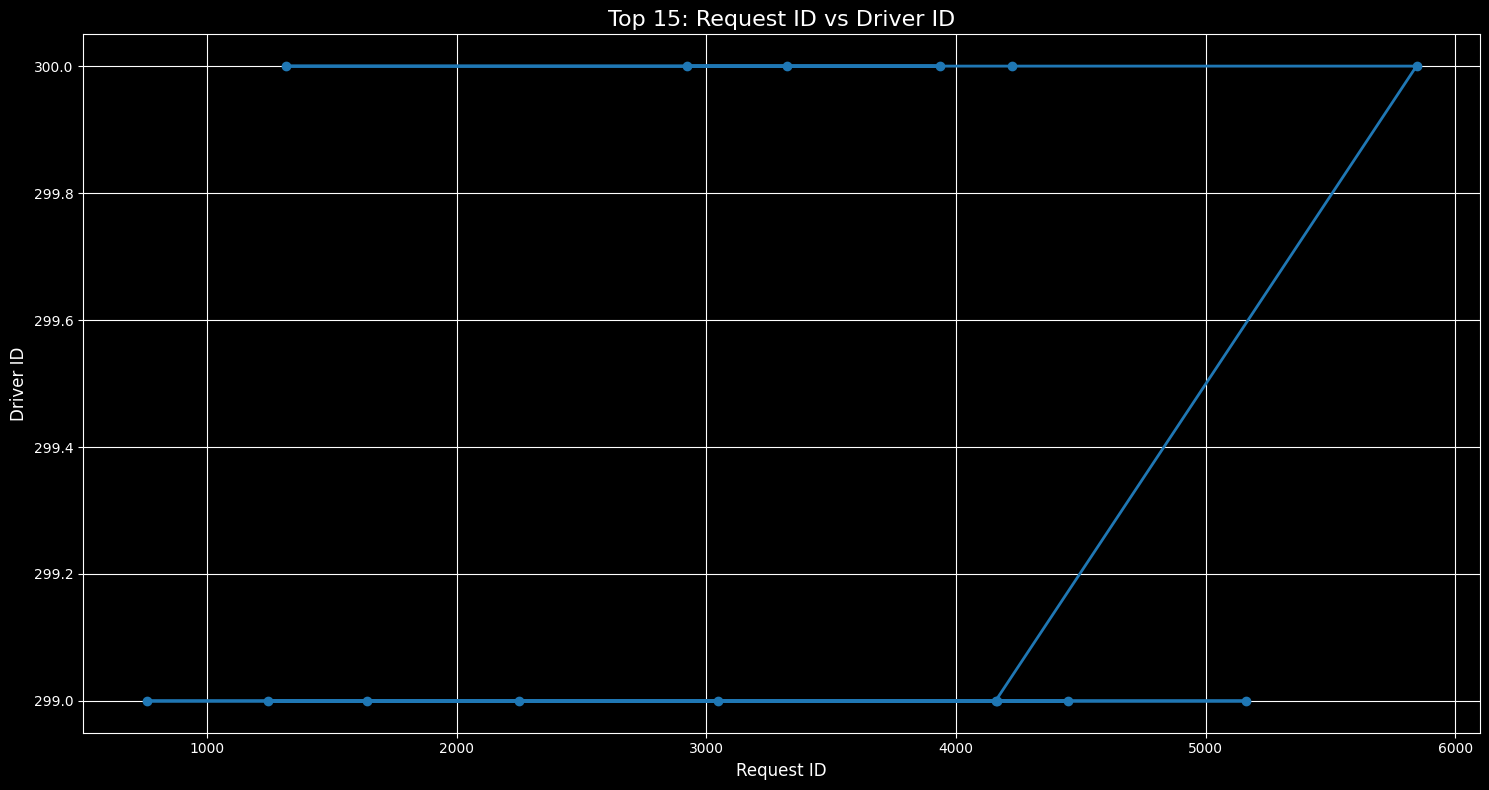

In [33]:
# Chart - 13 visualization code
plt.style.use('dark_background')

# Clean column names
md.columns = md.columns.str.strip()

# Optional: Convert columns to numeric (in case they're strings)
md['Driver id'] = pd.to_numeric(md['Driver id'], errors='coerce')
md['Request id'] = pd.to_numeric(md['Request id'], errors='coerce')

# Drop rows with missing values
md = md.dropna(subset=['Driver id', 'Request id'])

# Sort by Driver id descending and take top 15
top_rd = md[['Request id', 'Driver id']].sort_values(by='Driver id',ascending=False).head(15)

# Plot
plt.figure(figsize=(15, 8))

plt.plot(top_rd['Request id'],top_rd['Driver id'],marker='o',color='tab:blue',linestyle='-',linewidth=2)

plt.xlabel("Request ID", fontsize=12)
plt.ylabel("Driver ID", fontsize=12)
plt.title("Top 15: Request ID vs Driver ID", fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above line chart is best for analyzing trends over a period of time for numerical variables.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above line chart:

1. For top 15 values the above line chart shows a steady Z pattern over a specific period of time.
2. Mostly the cab service request is handled by driver id's 299 and 300.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the driver id 299 and 300 are getting maximum business and also they are completing their business services successfully.

#### Chart - 14 - Correlation Heatmap

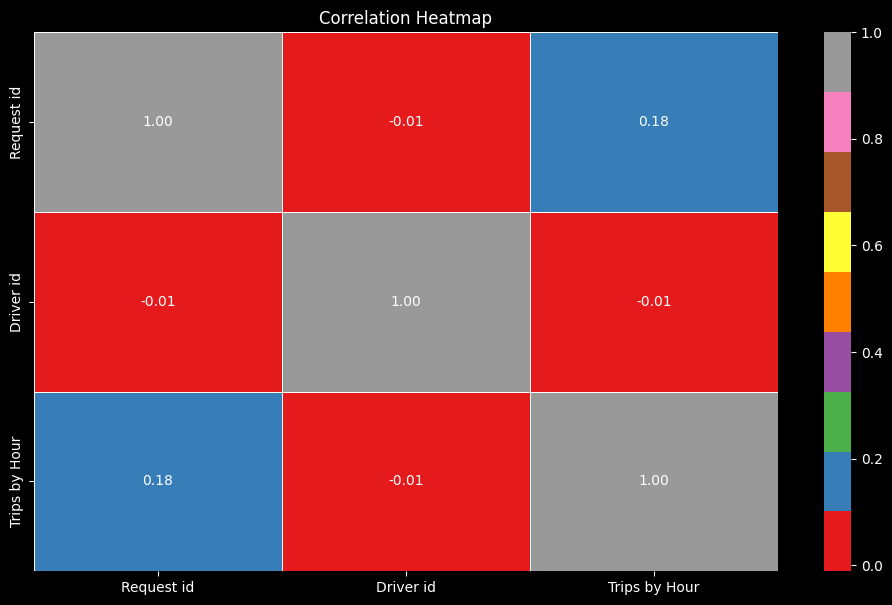

In [34]:
# Correlation Heatmap visualization code
plt.style.use('dark_background')
numerical = md.select_dtypes(include=['int64', 'float64'])

corr_matrix = numerical.corr().fillna(0)
plt.figure(figsize=(12,7))
sns.heatmap(corr_matrix, annot=True, cmap="Set1", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

##### 1. Why did you pick the specific chart?

The above heatmap is good for analyzing the correlation between various numerical values with each other and itself.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above heatmap:

1. Each variable has a perfect positive correlation (1.00) with itself, which is expected in every correlation matrix.
2. Request ID and Driver ID have almost no correlation (-0.01), indicating that request numbers and driver IDs are independent of each other.
3. Driver ID and Trips by Hour also show almost no correlation (-0.01), suggesting that the assigned driver does not have a relationship with the request hour.
4. Request ID and Trips by Hour have a very weak positive correlation (0.18), indicating a negligible linear relationship between request IDs and the hour of the request.

#### Chart - 15 - Pair Plot

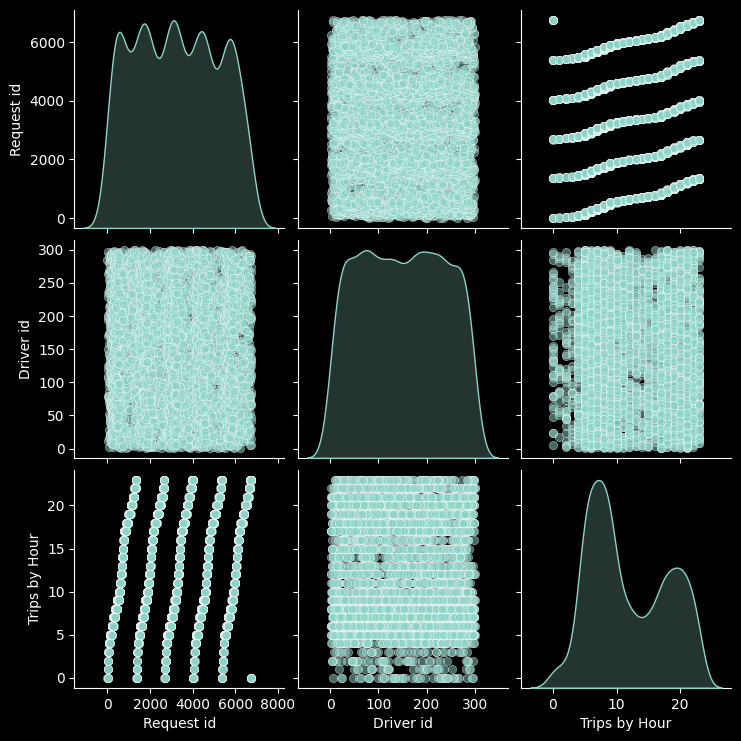

In [35]:
# Pair Plot visualization code
plt.style.use('dark_background')
numerical = md.select_dtypes(include=['int64', 'float64'])
numerical = numerical.dropna(axis=1, thresh=len(numerical) * 0.8)
sns.pairplot(numerical, diag_kind='kde', plot_kws={'alpha' : 0.5})
plt.show()

##### 1. Why did you pick the specific chart?

The pair plot is useful for visualizing the relationship between multiple numerical variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

1. The distributions of Request ID and Driver ID are spread across a wide range of values, indicating that both variables are well distributed throughout the dataset.
2. The scatter plots show no strong linear relationship between Request ID, Driver ID, and Trips by Hour, suggesting that request assignments and trip timings are independent of the identifier fields.
3. The points are widely scattered without distinct clusters or unusual outliers, indicating no significant association among the numeric variables.
4. The density plot for Trips by Hour shows two prominent peaks, indicating that Uber experiences higher request volumes during the morning and evening hours, reflecting peak travel periods.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

The following are some of the solutions to Business Objective:
1. Increase driver availability during peak hours: Deploy more drivers during busy morning and evening hours to reduce waiting time and increase completed trips.
2. Optimize driver allocation between Airport and City: Assign drivers to locations with higher demand so that ride requests can be fulfilled more efficiently.
3. Reduce trip cancellations:Improve driver response time and availability to minimize cancelled trips and enhance customer satisfaction.
4. Monitor key performance metrics: Regularly track Trip Completion Rate, Cancellation Rate, and No Cars Available Rate to measure performance and identify areas for improvement.

# **Conclusion**

The Uber Trip Analysis project successfully analyzed ride request data using Excel, SQL, and Python. Excel was used for data cleaning and creating an interactive dashboard, SQL was used to extract meaningful business insights, and Python was used for exploratory data analysis (EDA) and data visualization.

The analysis revealed that peak demand occurs during the morning and evening hours, while a significant number of requests remain unfulfilled due to No Cars Available. It also showed that trip cancellations and driver availability are major factors affecting service efficiency. By increasing driver availability during peak hours, optimizing driver allocation based on demand, and using historical data for demand forecasting, Uber can improve trip completion rates, reduce cancellations, and enhance customer satisfaction.

### ***Hurrah! You have successfully completed your EDA Uber Project !!!***